# Social Media Sentiment Analysis

### Project Description

Sentiment analysis is a Natural Language Processing (NLP) technique used to determine the emotional tone behind a piece of text. It is widely used to analyze opinions and feedback expressed on social media platforms such as Twitter.

In this project, a Deep Learning-based sentiment analysis model is developed to classify tweets as positive or negative. The text data is preprocessed using tokenization and padding, and a neural network model is trained using TensorFlow/Keras. The model learns patterns in the tweet text and predicts the sentiment of unseen tweets.

This project demonstrates how NLP and deep learning techniques can be applied to social media data to automatically understand public sentiment.

### Project Structure
✔ Introduction
✔ Import Libraries
✔ Load Dataset
✔ Data Preprocessing
✔ Tokenization & Padding
✔ Train Test Split
✔ Build Deep Learning Model (Embedding + LSTM)
✔ Train Model
✔ Model Evaluation
✔ Visualization of Results
✔ Conclusion

### Import Libraries

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

### Load Dataset

In [68]:
df = pd.read_csv("train.csv")
df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [69]:
df.info()
df['label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB


label
0    29720
1     2242
Name: count, dtype: int64

Label meaning:

0 → Positive
1 → Negative

### Text Column

The text column is:

tweet

Create features and target:

In [70]:
X = df['tweet']
y = df['label']

### Train Test Split

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Text Cleaning

In [72]:
# Import regex
import re

In [73]:
#Create cleaning function
def clean_text(text):
    
    text = text.lower()                     # convert to lowercase
    text = re.sub(r"http\S+", "", text)     # remove URLs
    text = re.sub(r"@\w+", "", text)        # remove mentions
    text = re.sub(r"#", "", text)           # remove hashtags
    text = re.sub(r"[^a-zA-Z\s]", "", text) # remove punctuation & numbers
    
    return text

In [74]:
#Apply cleaning
X_train = X_train.apply(clean_text)
X_test = X_test.apply(clean_text)

### Tokenization

In [75]:
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")   #oov_token means Out Of Vocabulary words

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

### Padding

In [76]:
#Make sequences same length
max_len = 50

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

### Build the LSTM Model

In [77]:
#Add Dropout to prevent overfitting
from tensorflow.keras.layers import Dropout

In [78]:
#Model creation
model = Sequential()

# Embedding layer
model.add(Embedding(input_dim=5000, output_dim=64, input_length=max_len))

# LSTM layer
model.add(LSTM(64))

# Dropout layer
model.add(Dropout(0.5))

# Output layer
model.add(Dense(1, activation='sigmoid'))

C:\Users\gokul\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


### Compile Model

In [79]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [80]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Train Model

In [81]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.9352 - loss: 0.2328 - val_accuracy: 0.9550 - val_loss: 0.1262
Epoch 2/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.9682 - loss: 0.0934 - val_accuracy: 0.9545 - val_loss: 0.1320
Epoch 3/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.9761 - loss: 0.0721 - val_accuracy: 0.9573 - val_loss: 0.1259
Epoch 4/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.9818 - loss: 0.0545 - val_accuracy: 0.9520 - val_loss: 0.1541
Epoch 5/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.9860 - loss: 0.0413 - val_accuracy: 0.9545 - val_loss: 0.1593


### Evaluate Model

In [82]:
loss, accuracy = model.evaluate(X_test_pad, y_test)

print("Test Accuracy:", accuracy)

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9584 - loss: 0.1417
Test Accuracy: 0.9544814825057983


### Visualization

Accuracy graph

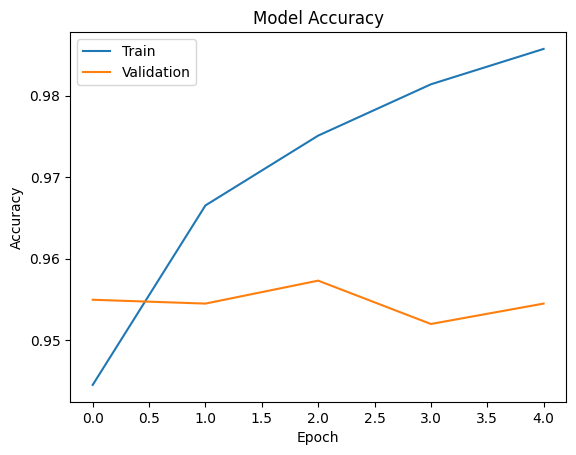

In [83]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend(["Train", "Validation"])

plt.show()

Loss graph

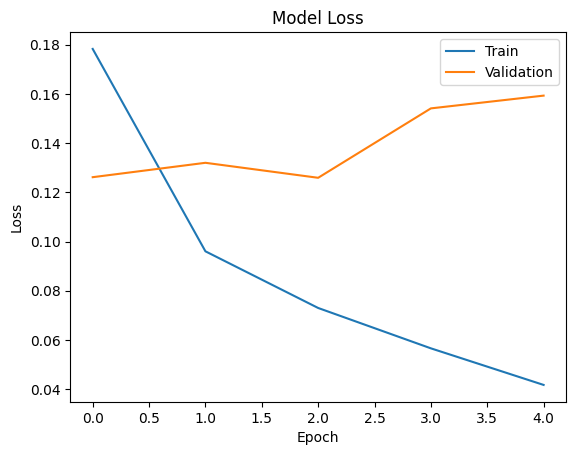

In [84]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.legend(["Train", "Validation"])

plt.show()

### Demo Prediction Cell

In [86]:
def predict_sentiment(text):

    text = clean_text(text)

    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=max_len)

    prediction = model.predict(padded)[0][0]

    print("Prediction score:", prediction)

    if prediction > 0.5:
        print("Positive 🙂")
    else:
        print("Negative 😞")

Testing :

In [87]:
predict_sentiment("I love this product")
predict_sentiment("This is the worst thing I ever bought")
predict_sentiment("I hate this movie")
predict_sentiment("This phone is amazing")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
Prediction score: 0.00018659155
Negative 😞
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Prediction score: 0.03587512
Negative 😞
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Prediction score: 0.027105428
Negative 😞
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Prediction score: 4.4750075e-05
Negative 😞


In [95]:
df['label'].value_counts()

label
0    29720
1     2242
Name: count, dtype: int64

The dataset is highly imbalanced, with approximately 93% negative tweets and only 7% positive tweets. Due to this imbalance, the model tends to predict the negative class more frequently. Despite this, the model achieved a test accuracy of 95.44%.

### Balance the dataset using undersampling

In [96]:
neg = df[df['label']==0]
pos = df[df['label']==1]

neg_sample = neg.sample(len(pos))

df_balanced = pd.concat([neg_sample, pos])

In [97]:
#Shuffle the balanced dataset. This avoids grouped classes.
df_balanced = df_balanced.sample(frac=1, random_state=42)

#Separate features and label
X = df_balanced['tweet']
y = df_balanced['label']

#Train–test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Fit tokenizer again
tokenizer.fit_on_texts(X_train)

#Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

#Pad sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

In [98]:
#Train model again
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5417 - loss: 1.1937 - val_accuracy: 0.6600 - val_loss: 0.5937
Epoch 2/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.7772 - loss: 0.4718 - val_accuracy: 0.8261 - val_loss: 0.3984
Epoch 3/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9369 - loss: 0.1912 - val_accuracy: 0.8294 - val_loss: 0.4495
Epoch 4/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9619 - loss: 0.1138 - val_accuracy: 0.8317 - val_loss: 0.4520
Epoch 5/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9829 - loss: 0.0630 - val_accuracy: 0.8339 - val_loss: 0.4913


In [99]:
loss, accuracy = model.evaluate(X_test_pad, y_test)

print("Test Accuracy:", accuracy)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8335 - loss: 0.5117
Test Accuracy: 0.8338907361030579


In [101]:
df_balanced['label'].value_counts()

label
0    2242
1    2242
Name: count, dtype: int64

Now the dataset is balanced

In [103]:
predict_sentiment("This is the worst thing ever")
predict_sentiment("Amazing service and great experience")
predict_sentiment("I hate this app")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Prediction score: 0.24791346
Negative 😞
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Prediction score: 0.060987495
Negative 😞
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Prediction score: 0.9770917
Positive 🙂


Initially, the dataset was highly imbalanced with a large number of negative tweets compared to positive tweets. To address this issue, undersampling was applied to balance the dataset. After retraining the model on the balanced dataset, the accuracy was 83.38%, which reflects a more realistic performance of the sentiment classification model.

### Visualization of results

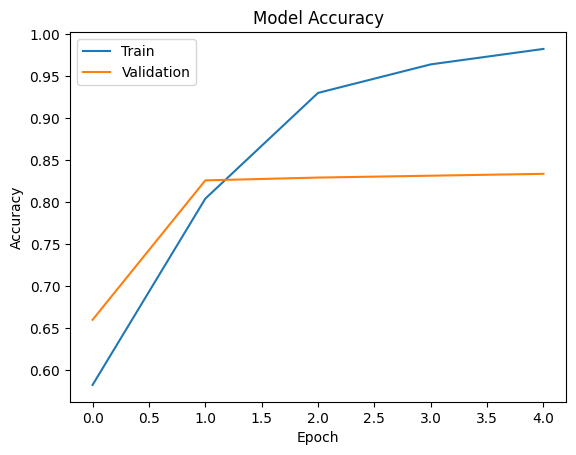

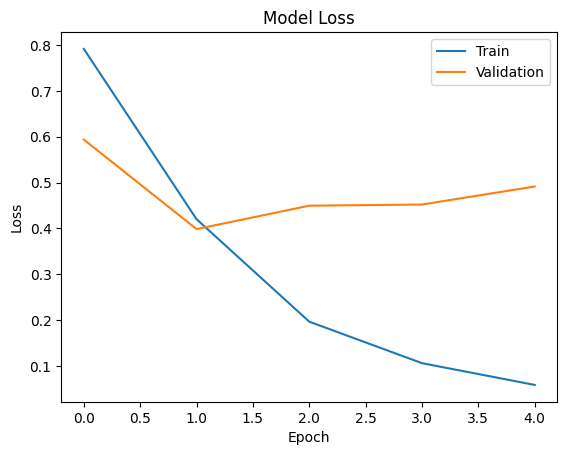

In [104]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])
plt.show()

### Save Model

In [105]:
model.save("sentiment_model.h5")

### Save tokenizer

In [106]:
import pickle

with open("tokenizer.pkl","wb") as f:
    pickle.dump(tokenizer,f)

### Conclusion

This project implemented a Social Media Sentiment Analysis model using Natural Language Processing (NLP) and Deep Learning. The tweets were first preprocessed and converted into numerical sequences using tokenization and padding. A deep learning model built with TensorFlow/Keras was then trained to classify tweets as positive or negative.

Initially, the dataset was highly imbalanced, with a large number of negative tweets compared to positive tweets. This imbalance resulted in a high accuracy but biased predictions toward the negative class. To address this issue, undersampling was applied to balance the dataset. After retraining the model on the balanced dataset, the model achieved an accuracy of 83.38%, which reflects a more reliable and realistic performance.

Overall, this project demonstrates how deep learning techniques can be applied to social media data to automatically analyze sentiment, which can be useful for businesses, brand monitoring, and understanding public opinion.